# Hybrid Anomaly Detection in Satellite Telemetry
## Aerospace Cybersecurity — SMAP P-1

Two-layer architecture:
- **Tier-1 (space segment)**: DPCM with leaky accumulator. On-board execution. Goal: filter the bulk of normal samples with negligible computational cost and high *recall*.
- **Tier-2 (ground segment)**: LSTM-Autoencoder. Goal: consolidate Tier-1 triggers into candidate events and remove false positives to increase overall precision.

**Architecture reference**: Hundman et al. (KDD 2018) for layer dimensions (2×80 units). The window `ls=30` and the autoencoder paradigm are design choices, justified by the duration of the injected attacks (50 and 300 samples).

## 0. Installation and dependencies

If running the next cell raises `ModuleNotFoundError: No module named 'tensorflow'`, uncomment the first line (or run it in a separate cell). On Windows, if `tensorflow` fails to install, use `tensorflow-cpu` (identical for this model, which does not require a GPU).

In [1]:
# !pip install tensorflow scikit-learn matplotlib seaborn pandas requests
# !pip install tensorflow-cpu  # alternativa si la anterior falla en Windows

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import requests
from matplotlib.colors import LinearSegmentedColormap

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Consistent aerospace colour palette for all plots
AERO_BLUE = "#163E83"
AERO_GOLD = "#F3C96B"
AERO_RED = "#C1272D"
AERO_GRAY = "#7A7A7A"
AERO_CMAP = LinearSegmentedColormap.from_list("aero", ["#EAECEF", AERO_BLUE])

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


## 1. Loading the NASA SMAP dataset — Channel P-1 (Power)

Channel P-1 is downloaded from the official Hundman repository (telemanom). If it is already available locally under `datasets/data/`, that copy is used.

In [2]:
import os
print("Current directory:", os.getcwd())
print("train/P-1.npy exists?", os.path.exists('datasets/data/train/P-1.npy'))
print("test/P-1.npy exists?", os.path.exists('datasets/data/test/P-1.npy'))

Current directory: c:\Users\María\Documents\Curso25-26\SegundoCuatri\AerospaceElectronics\FinalProject\FinalProject-EN
train/P-1.npy exists? True
test/P-1.npy exists? True


In [3]:
# Ruta a los datos, relativa al notebook
DATA_DIR = 'datasets/data'

def load_smap_channel(channel='P-1', split='train'):
    """Load an SMAP channel from datasets/data/{split}/{channel}.npy"""
    path = os.path.join(DATA_DIR, split, f'{channel}.npy')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Not found: {os.path.abspath(path)}\n"
            f"Make sure datasets/data/{split}/{channel}.npy exists next to the notebook."
        )
    return np.load(path)

def extract_telemetry(raw):
    """SMAP stores telemetry in column 0; the remaining columns are command one-hots."""
    return raw[:, 0].astype(np.float32) if raw.ndim > 1 else raw.flatten().astype(np.float32)


# --- Load ---
raw_train = load_smap_channel('P-1', 'train')
raw_test  = load_smap_channel('P-1', 'test')

train_data = extract_telemetry(raw_train)
test_base  = extract_telemetry(raw_test)

print(f"SMAP P-1 loaded from: {os.path.abspath(DATA_DIR)}")
print(f"train_data: {len(train_data)} samples  (shape raw: {raw_train.shape})")
print(f"test_base:  {len(test_base)} samples  (shape raw: {raw_test.shape})")


SMAP P-1 loaded from: c:\Users\María\Documents\Curso25-26\SegundoCuatri\AerospaceElectronics\FinalProject\FinalProject-EN\datasets\data
train_data: 2872 samples  (shape raw: (2872, 25))
test_base:  8505 samples  (shape raw: (8505, 25))


## 2. Cyber-physical attack injection

Two canonical man-in-the-middle attack types from the aerospace cybersecurity literature are injected:

| Attack | Type | Difficulty for DPCM | Parameters |
|---|---|---|---|
| **Point Injection** | Sudden constant offset | **Easy** (instantaneous error is large) | `start=1000, dur=50, mag=+0.8` |
| **Ramp MiTM** | Gradual drift | **Hard** (predictor adapts) | `start=3000, dur=300, slope=+0.005` |

A total of 350 attacked samples out of ~8500 gives a prevalence of ~4 %, consistent with real operational scenarios.

In [4]:
def attack_point_injection(data, start_idx, duration, magnitude):
    '''Point injection attack: adds a constant offset for `duration` samples.'''
    corrupted = data.copy()
    corrupted[start_idx : start_idx + duration] += magnitude
    return corrupted


def attack_ramp_injection(data, start_idx, duration, slope):
    '''Ramp MiTM attack: linearly increasing drift, hard to detect because
    the sample-to-sample instantaneous error is small (= slope).'''
    corrupted = data.copy()
    ramp = np.arange(duration) * slope
    end = min(start_idx + duration, len(corrupted))
    corrupted[start_idx : end] += ramp[: end - start_idx]
    return corrupted


# --- Canonical attack configuration ---
ATTACK_CONFIG = {
    'point': {'start': 1000, 'duration': 50,  'magnitude': 0.8},
    'ramp':  {'start': 3000, 'duration': 300, 'slope': 0.005},
}

# Sequential application
attacked_test = test_base.copy()
attacked_test = attack_point_injection(
    attacked_test,
    ATTACK_CONFIG['point']['start'],
    ATTACK_CONFIG['point']['duration'],
    ATTACK_CONFIG['point']['magnitude'],
)
attacked_test = attack_ramp_injection(
    attacked_test,
    ATTACK_CONFIG['ramp']['start'],
    ATTACK_CONFIG['ramp']['duration'],
    ATTACK_CONFIG['ramp']['slope'],
)

# Sample-level ground truth (0 = normal, 1 = injected attack)
y_true = np.zeros(len(test_base), dtype=int)
y_true[ATTACK_CONFIG['point']['start'] : ATTACK_CONFIG['point']['start'] + ATTACK_CONFIG['point']['duration']] = 1
y_true[ATTACK_CONFIG['ramp']['start']  : ATTACK_CONFIG['ramp']['start']  + ATTACK_CONFIG['ramp']['duration']]  = 1

print(f"Total test samples:         {len(attacked_test)}")
print(f"Attacked samples:           {int(y_true.sum())} ({100*y_true.mean():.2f}%)")
print(f"Normal samples:             {int((1-y_true).sum())}")


Total test samples:         8505
Attacked samples:           350 (4.12%)
Normal samples:             8155


## 3. Tier-1 — DPCM Cyber-Focused (on-board algorithm)

First-order predictor (`x̂(t) = x(t-1)`) combined with a **leaky accumulator** that enables detection of slow drifts (ramp attacks) while maintaining $O(1)$ computational cost per sample and $O(1)$ memory.

$$\text{acc}_t = \lambda \cdot \text{acc}_{t-1} + (x_t - x_{t-1})$$

When the threshold is exceeded, the accumulator resets to resume monitoring.

In [5]:
def run_tier1_cyber_focused(data, threshold, forget_factor=0.9):
    '''
    On-board Tier-1: DPCM + leaky accumulator.
    
    Parameters
    ----------
    data : np.ndarray  — time series (attacked_test)
    threshold : float  — threshold on the absolute accumulator
    forget_factor : float ∈ (0, 1) — λ of the leaky accumulator
    
    Returns
    -------
    triggers : np.ndarray — 0/1 per sample
    errors_acum : np.ndarray — |accumulator| at each t (for plotting)
    '''
    n = len(data)
    triggers = np.zeros(n, dtype=int)
    errors_acum = np.zeros(n)
    
    x_hat = data[0]
    acc = 0.0
    
    for t in range(1, n):
        e_t = data[t] - x_hat
        acc = forget_factor * acc + e_t
        errors_acum[t] = abs(acc)
        
        if abs(acc) > threshold:
            triggers[t] = 1
            acc = 0.0   # reset after alert
        
        x_hat = data[t]  # first-order DPCM update
    
    return triggers, errors_acum


# --- Final Tier-1 configuration (validated by prior sensitivity analysis) ---
UMBRAL_TIER1 = 0.025
FORGET_FACTOR = 0.9

triggers_tier1, errors_acum = run_tier1_cyber_focused(
    attacked_test, UMBRAL_TIER1, FORGET_FACTOR
)

muestras_enviadas = int(triggers_tier1.sum())
ahorro_bw = (1 - muestras_enviadas / len(attacked_test)) * 100

print(f"--- TIER-1 DPCM CYBER-FOCUSED ---")
print(f"Threshold:            {UMBRAL_TIER1}")
print(f"Forgetting factor:    {FORGET_FACTOR}")
print(f"Samples forwarded:    {muestras_enviadas} of {len(attacked_test)}")
print(f"Bandwidth saving:     {ahorro_bw:.2f}%")


--- TIER-1 DPCM CYBER-FOCUSED ---
Threshold:            0.025
Forgetting factor:    0.9
Samples forwarded:    4974 of 8505
Bandwidth saving:     41.52%


## 4. Tier-1 evaluation

Standard binary classification metrics are reported at sample level. The low precision is **expected and desirable** at this stage of the pipeline: Tier-1 prioritises capturing the attack (recall) over alert purity (precision). It is Tier-2 that will raise the final precision.

--- TIER-1 METRICS ---
Precision : 0.0392
Recall    : 0.5571
F1        : 0.0733
BW Saving : 41.52%

              precision    recall  f1-score   support

      Normal       0.96      0.41      0.58      8155
      Attack       0.04      0.56      0.07       350

    accuracy                           0.42      8505
   macro avg       0.50      0.49      0.33      8505
weighted avg       0.92      0.42      0.56      8505



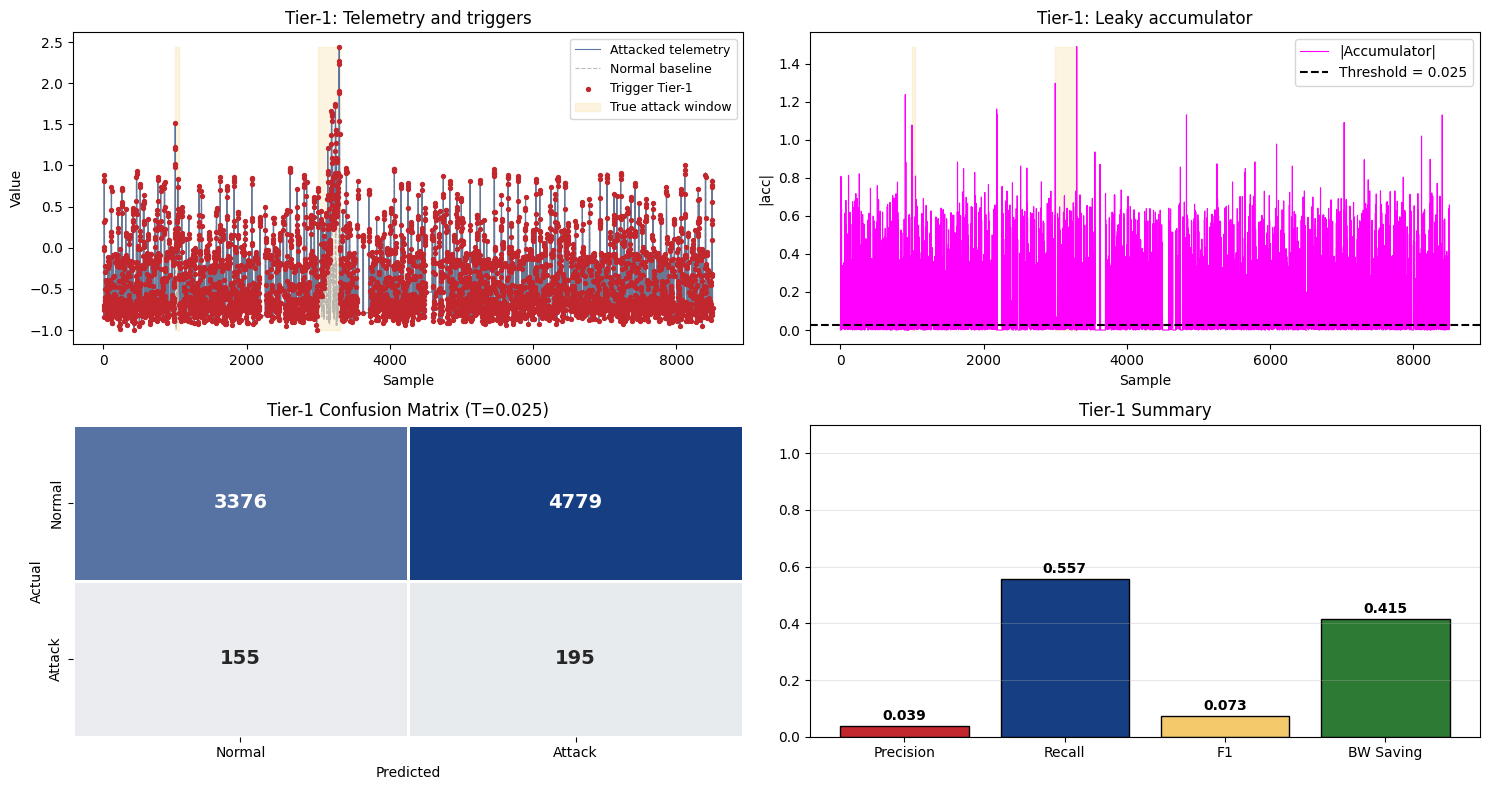

In [6]:
def plot_confusion(y_true, y_pred, title, ax=None):
    '''Confusion matrix with aerospace colour palette.'''
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=AERO_CMAP, cbar=False,
                linewidths=1, linecolor='white',
                annot_kws={"fontsize": 14, "fontweight": "bold"},
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'], ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    return ax


# Métricas Tier-1
prec_t1 = precision_score(y_true, triggers_tier1, zero_division=0)
rec_t1  = recall_score(y_true, triggers_tier1, zero_division=0)
f1_t1   = f1_score(y_true, triggers_tier1, zero_division=0)

print(f"--- TIER-1 METRICS ---")
print(f"Precision : {prec_t1:.4f}")
print(f"Recall    : {rec_t1:.4f}")
print(f"F1        : {f1_t1:.4f}")
print(f"BW Saving : {ahorro_bw:.2f}%")
print()
print(classification_report(y_true, triggers_tier1, target_names=['Normal', 'Attack']))

# --- Visualización combinada ---
fig = plt.figure(figsize=(15, 8))

# Subplot 1: telemetry + triggers
ax1 = plt.subplot(2, 2, 1)
ax1.plot(attacked_test, color=AERO_BLUE, alpha=0.7, lw=0.8, label='Attacked telemetry')
ax1.plot(test_base, color=AERO_GRAY, ls='--', alpha=0.5, lw=0.8, label='Normal baseline')
idx_trig = np.where(triggers_tier1 == 1)[0]
ax1.scatter(idx_trig, attacked_test[idx_trig], color=AERO_RED, s=8, label='Trigger Tier-1', zorder=5)
ax1.fill_between(range(len(y_true)), attacked_test.min(), attacked_test.max(),
                 where=y_true == 1, color=AERO_GOLD, alpha=0.2, label='True attack window')
ax1.set_title("Tier-1: Telemetry and triggers")
ax1.set_xlabel("Sample"); ax1.set_ylabel("Value")
ax1.legend(loc='upper right', fontsize=9)

# Subplot 2: accumulated error vs threshold
ax2 = plt.subplot(2, 2, 2)
ax2.plot(errors_acum, color='magenta', lw=0.8, label='|Accumulator|')
ax2.axhline(UMBRAL_TIER1, color='black', ls='--', label=f'Threshold = {UMBRAL_TIER1}')
ax2.fill_between(range(len(y_true)), 0, errors_acum.max(),
                 where=y_true == 1, color=AERO_GOLD, alpha=0.2)
ax2.set_title("Tier-1: Leaky accumulator")
ax2.set_xlabel("Sample"); ax2.set_ylabel("|acc|")
ax2.legend()

# Subplot 3: confusion matrix
ax3 = plt.subplot(2, 2, 3)
plot_confusion(y_true, triggers_tier1, f"Tier-1 Confusion Matrix (T={UMBRAL_TIER1})", ax=ax3)

# Subplot 4: summary metrics
ax4 = plt.subplot(2, 2, 4)
metrics_t1 = ['Precision', 'Recall', 'F1', 'BW Saving']
values_t1 = [prec_t1, rec_t1, f1_t1, ahorro_bw/100]
colors_t1 = [AERO_RED, AERO_BLUE, AERO_GOLD, '#2C7A34']
bars = ax4.bar(metrics_t1, values_t1, color=colors_t1, edgecolor='black')
for bar, v in zip(bars, values_t1):
    ax4.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
             ha='center', fontweight='bold')
ax4.set_ylim(0, 1.1)
ax4.set_title("Tier-1 Summary")
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Tier-2 — Sequence preparation (X_train)

The autoencoder is trained **exclusively on `train_data`** (clean data, attack-free). The rationale is:
1. The AE learns to reconstruct the normal pattern of the P-1 telemetry.
2. At inference time, windows containing an attack will show high reconstruction error because the model has never seen them.

**Sliding windows with stride 1** to maximise dataset size and temporal coverage.

**Important**: the `MinMaxScaler` is fitted **only on `train_data`**. Fitting on attacked data would contaminate the normalisation and bias reconstruction errors (data leak).

In [7]:
# --- Tier-2 hyperparameters ---
WINDOW_SIZE = 30       # sequence length (ls)
STRIDE = 1             # stride = 1 for maximum overlap
LSTM_UNITS = 80        # units per LSTM layer (following Hundman 2018)
BATCH_SIZE = 64
EPOCHS_MAX = 50
VAL_SPLIT = 0.15       # final fraction of train_data reserved for validation

# --- 5.1 Normalisation (fit on train_data ONLY) ---
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data.reshape(-1, 1)).flatten()

# Apply the same scaler to attacked_test (WITHOUT refitting)
attacked_scaled = scaler.transform(attacked_test.reshape(-1, 1)).flatten()


# --- 5.2 Ventanización ---
def create_sequences(series, window_size, stride=1):
    '''Sliding windows for the autoencoder. Shape: (N, window_size, 1).'''
    n = len(series)
    n_windows = (n - window_size) // stride + 1
    X = np.zeros((n_windows, window_size, 1), dtype=np.float32)
    for i in range(n_windows):
        s = i * stride
        X[i, :, 0] = series[s : s + window_size]
    return X


X_train = create_sequences(train_scaled, WINDOW_SIZE, STRIDE)

print(f"train_data original:  {train_data.shape}")
print(f"train_scaled:         {train_scaled.shape}  range=[{train_scaled.min():.3f}, {train_scaled.max():.3f}]")
print(f"X_train (windows):    {X_train.shape}  → {X_train.shape[0]} sequences of {WINDOW_SIZE} steps × 1 feature")


train_data original:  (2872,)
train_scaled:         (2872,)  range=[0.000, 1.000]
X_train (windows):    (2843, 30, 1)  → 2843 sequences of 30 steps × 1 feature


## 6. Tier-2 — LSTM-Autoencoder architecture

Symmetric encoder-decoder structure:

```
Input (30, 1)
   ↓
LSTM(80, return_sequences=True)      ← Encoder L1
   ↓
LSTM(80, return_sequences=False)     ← Encoder L2 / bottleneck (80-dim)
   ↓
RepeatVector(30)                     ← Replicates the latent vector 30 times
   ↓
LSTM(80, return_sequences=True)      ← Decoder L1
   ↓
LSTM(80, return_sequences=True)      ← Decoder L2
   ↓
TimeDistributed(Dense(1))            ← Point-wise reconstruction
   ↓
Output (30, 1)
```

**Loss**: MSE between input window and reconstructed window.
**Optimiser**: Adam (lr=1e-3) as in Hundman et al. (2018).

In [8]:
def build_lstm_autoencoder(window_size=30, n_features=1, units=80):
    '''Symmetric LSTM-AE with a bottleneck of `units` dimensions.'''
    inputs = Input(shape=(window_size, n_features), name='input_window')
    
    # Encoder
    x = LSTM(units, activation='tanh', return_sequences=True, name='enc_lstm_1')(inputs)
    latent = LSTM(units, activation='tanh', return_sequences=False, name='enc_lstm_2_bottleneck')(x)
    
    # Bridge: repeats the latent vector across time
    x = RepeatVector(window_size, name='repeat')(latent)
    
    # Decoder (symmetric to the encoder)
    x = LSTM(units, activation='tanh', return_sequences=True, name='dec_lstm_1')(x)
    x = LSTM(units, activation='tanh', return_sequences=True, name='dec_lstm_2')(x)
    outputs = TimeDistributed(Dense(n_features), name='reconstruction')(x)
    
    model = Model(inputs, outputs, name='LSTM_Autoencoder_Tier2')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
    )
    return model


autoencoder = build_lstm_autoencoder(WINDOW_SIZE, n_features=1, units=LSTM_UNITS)
autoencoder.summary()


Model: "LSTM_Autoencoder_Tier2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_window (InputLayer)       │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm_1 (LSTM)               │ (None, 30, 80)         │        26,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm_2_bottleneck (LSTM)    │ (None, 80)             │        51,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 30, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm_1 (LSTM)               │ (None, 30, 80)         │        51,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm_2 (LSTM)               │ (None, 30, 80)         │        51,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 30, 1)          │            81 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,881 (706.57 KB)

 Trainable params: 180,881 (706.57 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Tier-2 — Training

- **EarlyStopping** with `patience=5` on `val_loss` and best-weight restoration (Hundman's criterion to prevent overfitting).
- **Validation**: final 15 % of `X_train` (temporally separated — not shuffled, because it is a time series).
- The target is `X_train` (the AE learns to reconstruct itself).

X_tr:  (2416, 30, 1)
X_val: (427, 30, 1)
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - loss: 0.0460 - val_loss: 0.0489
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0322 - val_loss: 0.0329
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0223 - val_loss: 0.0223
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0167 - val_loss: 0.0178
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0146 - val_loss: 0.0165
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0137 - val_loss: 0.0156
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0128 - val_loss: 0.0145
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0120 - val_loss: 0.0138
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0115 - val_loss: 0.0125
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0105 - val_loss: 0.0121
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0098 - val_loss: 0.0122
Epoch 12/50
38/38 ━━━━

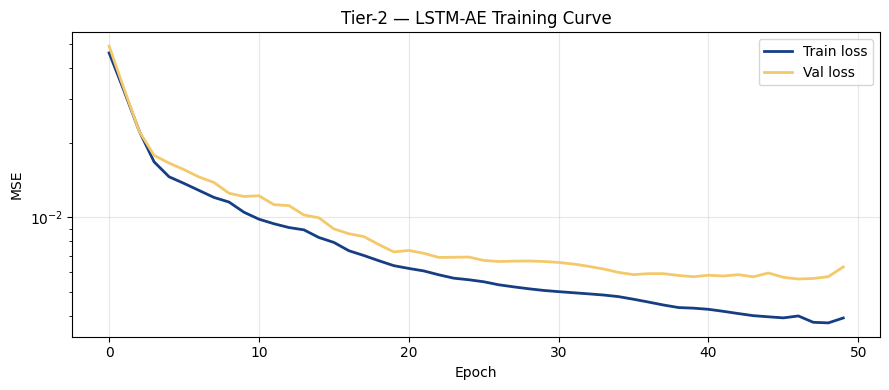


Best val_loss: 5.64e-03


In [9]:
# Temporal train/val split (NO shuffle for time series)
n_train = int(len(X_train) * (1 - VAL_SPLIT))
X_tr = X_train[:n_train]
X_val = X_train[n_train:]

print(f"X_tr:  {X_tr.shape}")
print(f"X_val: {X_val.shape}")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

history = autoencoder.fit(
    X_tr, X_tr,           # autoencoder: target = input
    validation_data=(X_val, X_val),
    epochs=EPOCHS_MAX,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    shuffle=True,          # windows are shuffled during training (they are independent)
    verbose=1,
)

# --- Training curve ---
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'], color=AERO_BLUE, lw=2, label='Train loss')
plt.plot(history.history['val_loss'], color=AERO_GOLD, lw=2, label='Val loss')
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.title("Tier-2 — LSTM-AE Training Curve")
plt.legend(); plt.grid(alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"\nBest val_loss: {min(history.history['val_loss']):.2e}")


## 8. Tier-2 — Reconstruction threshold

Reconstruction errors are computed over **the clean training set** (`X_train`). The resulting distribution shows how well the AE reconstructs normal data. The threshold `τ₂` is set above that distribution:

$$\tau_2 = \mu(\text{err}_{\text{train}}) + k \cdot \sigma(\text{err}_{\text{train}})$$

where $k$ is a hyperparameter (typically 3–6). Alternatively, a high percentile (p99 or p99.5) can be used, which is more robust to non-Gaussian distributions.

Reconstruction errors on clean training data:
  µ:         4.185708e-03
  σ:         2.026987e-03
  µ + 3σ:    1.026667e-02
  µ + 5σ:    1.432064e-02
  p99:       1.109289e-02
  p99.5:     1.314629e-02

→ Selected Tier-2 threshold (µ + 4σ): 1.314629e-02


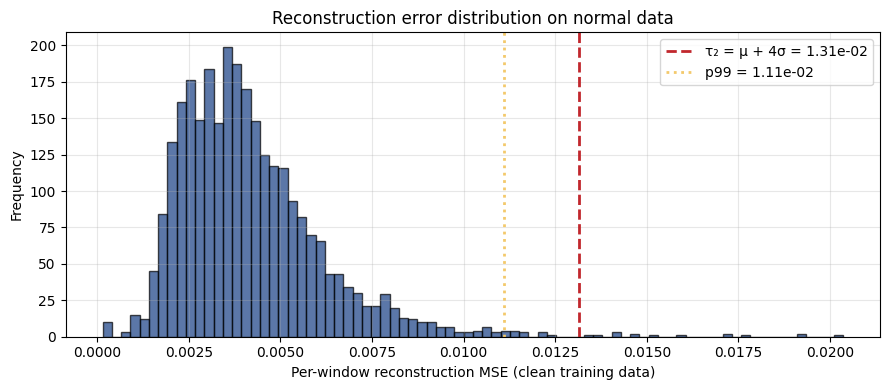

In [10]:
# Reconstruction errors on CLEAN data
recon_train = autoencoder.predict(X_train, batch_size=BATCH_SIZE, verbose=0)
err_train = np.mean((X_train - recon_train) ** 2, axis=(1, 2))  # MSE por ventana

mu_err, sigma_err = err_train.mean(), err_train.std()
p99  = np.percentile(err_train, 99)
p995 = np.percentile(err_train, 99.5)

print(f"Reconstruction errors on clean training data:")
print(f"  µ:         {mu_err:.6e}")
print(f"  σ:         {sigma_err:.6e}")
print(f"  µ + 3σ:    {mu_err + 3*sigma_err:.6e}")
print(f"  µ + 5σ:    {mu_err + 5*sigma_err:.6e}")
print(f"  p99:       {p99:.6e}")
print(f"  p99.5:     {p995:.6e}")

# Threshold selection (adjust `k` after reviewing results)
K_SIGMA = 4
#THRESHOLD_TIER2 = mu_err + K_SIGMA * sigma_err
THRESHOLD_TIER2 = np.percentile(err_train, 99.5)
# more conservative alternative: THRESHOLD_TIER2 = p995

print(f"\n→ Selected Tier-2 threshold (µ + {K_SIGMA}σ): {THRESHOLD_TIER2:.6e}")

# Error distribution
plt.figure(figsize=(9, 4))
plt.hist(err_train, bins=80, color=AERO_BLUE, alpha=0.7, edgecolor='black')
plt.axvline(THRESHOLD_TIER2, color=AERO_RED, ls='--', lw=2,
            label=f'τ₂ = µ + {K_SIGMA}σ = {THRESHOLD_TIER2:.2e}')
plt.axvline(p99, color=AERO_GOLD, ls=':', lw=2, label=f'p99 = {p99:.2e}')
plt.xlabel("Per-window reconstruction MSE (clean training data)")
plt.ylabel("Frequency")
plt.title("Reconstruction error distribution on normal data")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Tier-2 auxiliary functions (support definitions)

Defines the three helper functions required by the grid search: consolidation of triggers into events, evaluation of each event with the autoencoder, and projection of event decisions to sample level.

In [11]:
def consolidate_triggers_into_events(triggers, max_gap=15):
    """Group contiguous triggers (separated by <= max_gap) into events [start, end]."""
    idx = np.where(triggers == 1)[0]
    if len(idx) == 0:
        return []
    
    events = []
    s = idx[0]
    e = idx[0]
    for i in idx[1:]:
        if i - e <= max_gap:
            e = i
        else:
            events.append((s, e))
            s = i
            e = i
    events.append((s, e))
    return events


def evaluate_event_with_ae(event_start, event_end, data_scaled, model, window_size=30):
    """Extract windows overlapping the event (with padding), reconstruct them,
    and return the maximum and mean reconstruction error."""
    pad = window_size // 2
    ctx_start = max(0, event_start - pad)
    ctx_end   = min(len(data_scaled), event_end + pad + 1)
    
    if ctx_end - ctx_start < window_size:
        return 0.0, 0.0
    
    n_windows = ctx_end - ctx_start - window_size + 1
    windows = np.zeros((n_windows, window_size, 1), dtype=np.float32)
    for i in range(n_windows):
        windows[i, :, 0] = data_scaled[ctx_start + i : ctx_start + i + window_size]
    
    recon = model.predict(windows, batch_size=BATCH_SIZE, verbose=0)
    errs = np.mean((windows - recon) ** 2, axis=(1, 2))
    return errs.max(), errs.mean()


def build_sample_predictions(events, confirmed_mask, n_samples):
    """Project event decisions to sample level."""
    y_pred = np.zeros(n_samples, dtype=int)
    for (s, e), conf in zip(events, confirmed_mask):
        if conf:
            y_pred[s:e+1] = 1
    return y_pred


print("Auxiliary functions defined:")
print(" - consolidate_triggers_into_events")
print(" - evaluate_event_with_ae")
print(" - build_sample_predictions")

Auxiliary functions defined:
 - consolidate_triggers_into_events
 - evaluate_event_with_ae
 - build_sample_predictions


## 9. End-to-end pipeline as a parametrisable function

Encapsulates the full Tier-1 → consolidation → Tier-2 → metrics flow in `run_hybrid_pipeline()`, allowing it to be called with any combination of `MAX_GAP` and threshold without rewriting code. The already-trained autoencoder is reused on every call.

In [12]:
def run_hybrid_pipeline(triggers_tier1, attacked_scaled, y_true, autoencoder,
                        err_train, max_gap, threshold_config,
                        window_size=30, verbose=False):
    """
    Run the Tier-1 → consolidation → Tier-2 → metrics pipeline.
    """
    # --- Threshold ---
    if threshold_config['method'] == 'sigma':
        k = threshold_config['k']
        tau2 = err_train.mean() + k * err_train.std()
        thr_label = f"µ+{k}σ"
    elif threshold_config['method'] == 'percentile':
        p = threshold_config['p']
        tau2 = np.percentile(err_train, p)
        thr_label = f"p{p}"

    # --- Consolidation ---
    events = consolidate_triggers_into_events(triggers_tier1, max_gap=max_gap)
    n_events = len(events)
    if n_events == 0:
        return {
            'max_gap': max_gap, 'threshold_label': thr_label, 'tau2': tau2,
            'n_events': 0, 'n_confirmed': 0,
            'precision': 0.0, 'recall': 0.0, 'f1': 0.0,
            'events': [], 'event_confirmed': np.array([]),
            'y_pred': np.zeros(len(attacked_scaled), dtype=int),
        }

    # --- Tier-2 inference on events ---
    event_confirmed = np.zeros(n_events, dtype=bool)
    for i, (s, e) in enumerate(events):
        err_max, _ = evaluate_event_with_ae(s, e, attacked_scaled,
                                            autoencoder, window_size)
        event_confirmed[i] = err_max > tau2

    # --- Sample-level prediction ---
    y_pred = build_sample_predictions(events, event_confirmed, len(attacked_scaled))

    # --- Metrics ---
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    result = {
        'max_gap': max_gap,
        'threshold_label': thr_label,
        'tau2': tau2,
        'n_events': n_events,
        'n_confirmed': int(event_confirmed.sum()),
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'events': events,
        'event_confirmed': event_confirmed,
        'y_pred': y_pred,
    }

    if verbose:
        print(f"  gap={max_gap:3d}  thr={thr_label:>8s}  eventos={n_events:4d}  confirm={result['n_confirmed']:3d}  P={prec:.3f}  R={rec:.3f}  F1={f1:.3f}")

    return result


# Verification: run with original parameters
result_original = run_hybrid_pipeline(
    triggers_tier1, attacked_scaled, y_true, autoencoder, err_train,
    max_gap=15, threshold_config={'method': 'sigma', 'k': 4}, verbose=True
)
print(f"\nVerification: original values reproduced correctly")

  gap= 15  thr=    µ+4σ  eventos=  14  confirm=  9  P=0.047  R=1.000  F1=0.090

Verification: original values reproduced correctly


## 10. Grid search: parameter sweep

Evaluates 4 values of `MAX_GAP` × 3 threshold criteria = 12 combinations, calling `run_hybrid_pipeline()` for each. Produces a comparison table of Precision / Recall / F1 to select the optimal configuration.

In [13]:
import pandas as pd
import time

gap_values = [3, 5, 10, 15]
threshold_configs = [
    {'method': 'percentile', 'p': 99.0},
    {'method': 'percentile', 'p': 99.5},
    {'method': 'sigma', 'k': 5},
]

results = []
t0 = time.time()
print("Running grid search (12 combinations)...")
print("-" * 75)

for gap in gap_values:
    for thr_cfg in threshold_configs:
        r = run_hybrid_pipeline(
            triggers_tier1, attacked_scaled, y_true, autoencoder, err_train,
            max_gap=gap, threshold_config=thr_cfg, verbose=True
        )
        results.append(r)

print("-" * 75)
print(f"Grid search completo en {time.time() - t0:.1f} s")

# --- Tabla resumen ---
df = pd.DataFrame([{
    'MAX_GAP': r['max_gap'],
    'Threshold': r['threshold_label'],
    'τ₂': f"{r['tau2']:.2e}",
    'No. events': r['n_events'],
    'Confirmed': r['n_confirmed'],
    'Precision': round(r['precision'], 3),
    'Recall': round(r['recall'], 3),
    'F1': round(r['f1'], 3),
} for r in results])

print("\n" + "="*75)
print("RESULTS TABLE — SENSITIVITY ANALYSIS")
print("="*75)
print(df.to_string(index=False))
print()

# --- Mejor configuración por F1 ---
best_idx = df['F1'].idxmax()
print(f"Best F1: configuration #{best_idx}")
print(df.iloc[best_idx].to_string())

Running grid search (12 combinations)...
---------------------------------------------------------------------------
  gap=  3  thr=   p99.0  eventos= 353  confirm= 58  P=0.124  R=0.709  F1=0.211
  gap=  3  thr=   p99.5  eventos= 353  confirm= 28  P=0.187  R=0.629  F1=0.288
  gap=  3  thr=    µ+5σ  eventos= 353  confirm= 21  P=0.253  R=0.629  F1=0.361
  gap=  5  thr=   p99.0  eventos=  72  confirm= 29  P=0.052  R=0.877  F1=0.098
  gap=  5  thr=   p99.5  eventos=  72  confirm= 16  P=0.062  R=0.714  F1=0.114
  gap=  5  thr=    µ+5σ  eventos=  72  confirm= 12  P=0.078  R=0.711  F1=0.141
  gap= 10  thr=   p99.0  eventos=  17  confirm= 13  P=0.046  R=1.000  F1=0.088
  gap= 10  thr=   p99.5  eventos=  17  confirm=  7  P=0.053  R=1.000  F1=0.101
  gap= 10  thr=    µ+5σ  eventos=  17  confirm=  7  P=0.053  R=1.000  F1=0.101
  gap= 15  thr=   p99.0  eventos=  14  confirm= 12  P=0.045  R=1.000  F1=0.085
  gap= 15  thr=   p99.5  eventos=  14  confirm=  7  P=0.053  R=1.000  F1=0.101
  gap= 15  thr

In [14]:
# Celda de exploración extra
extra_gaps = [1, 2, 4]
print("Additional exploration:")
for gap in extra_gaps:
    for thr_cfg in [{'method': 'percentile', 'p': 99.5}]:
        r = run_hybrid_pipeline(
            triggers_tier1, attacked_scaled, y_true, autoencoder, err_train,
            max_gap=gap, threshold_config=thr_cfg, verbose=True
        )
        results.append(r)

Additional exploration:
  gap=  1  thr=   p99.5  eventos=1706  confirm=102  P=0.441  R=0.429  F1=0.435
  gap=  2  thr=   p99.5  eventos= 751  confirm= 49  P=0.318  R=0.531  F1=0.398
  gap=  4  thr=   p99.5  eventos= 153  confirm= 23  P=0.102  R=0.691  F1=0.177


## 11. Sensitivity analysis visualisation

Shows Precision / Recall / F1 as a function of `MAX_GAP` at fixed threshold `p99.5`, and the Precision–Recall space with F1 iso-curves. The threshold is fixed by statistical criterion (previous section); this figure shows sensitivity to the only remaining parameter.

C:\Users\María\AppData\Local\Temp\ipykernel_5344\2236184756.py:53: RuntimeWarning: divide by zero encountered in divide
  prec_iso = (f1_target * from_recall) / (2 * from_recall - f1_target)


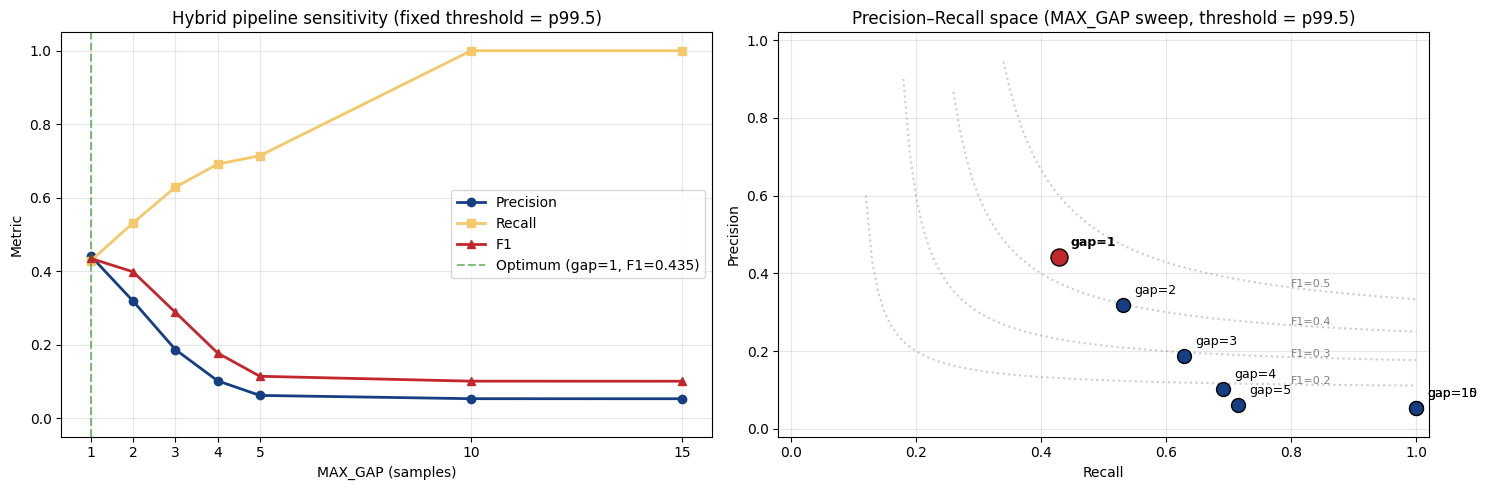


Parameter sweep summary (threshold = p99.5):
  gap= 1  P=0.441  R=0.429  F1=0.435 ← OPTIMUM
  gap= 2  P=0.318  R=0.531  F1=0.398
  gap= 3  P=0.187  R=0.629  F1=0.288
  gap= 4  P=0.102  R=0.691  F1=0.177
  gap= 5  P=0.062  R=0.714  F1=0.114
  gap=10  P=0.053  R=1.000  F1=0.101
  gap=15  P=0.053  R=1.000  F1=0.101


In [15]:
# Filter results with p99.5 threshold and sort by gap
results_p995 = sorted(
    [r for r in results if r['threshold_label'] == 'p99.5'],
    key=lambda r: r['max_gap']
)

gaps = [r['max_gap'] for r in results_p995]
precs = [r['precision'] for r in results_p995]
recs = [r['recall'] for r in results_p995]
f1s = [r['f1'] for r in results_p995]

# Identify the optimum
best_gap_idx = np.argmax(f1s)
best_gap = gaps[best_gap_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Subplot 1: Precision, Recall and F1 vs MAX_GAP ---
ax = axes[0]
ax.plot(gaps, precs, marker='o', lw=2, color=AERO_BLUE, label='Precision')
ax.plot(gaps, recs, marker='s', lw=2, color=AERO_GOLD, label='Recall')
ax.plot(gaps, f1s, marker='^', lw=2, color=AERO_RED, label='F1')

# Línea vertical en el óptimo
ax.axvline(best_gap, color='green', ls='--', alpha=0.5,
           label=f'Optimum (gap={best_gap}, F1={f1s[best_gap_idx]:.3f})')

ax.set_xlabel("MAX_GAP (samples)")
ax.set_ylabel("Metric")
ax.set_title("Hybrid pipeline sensitivity (fixed threshold = p99.5)")
ax.legend(fontsize=10, loc='center right')
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(gaps)

# --- Subplot 2: Precision–Recall space ---
ax = axes[1]
for i, r in enumerate(results_p995):
    is_best = (i == best_gap_idx)
    ax.scatter(r['recall'], r['precision'],
               s=150 if is_best else 100,
               edgecolor='black',
               color=AERO_RED if is_best else AERO_BLUE,
               zorder=3)
    ax.annotate(f"gap={r['max_gap']}",
                (r['recall'], r['precision']),
                textcoords="offset points", xytext=(8, 8), fontsize=9,
                fontweight='bold' if is_best else 'normal')

# Isolíneas de F1 como referencia
from_recall = np.linspace(0.01, 1, 100)
for f1_target in [0.2, 0.3, 0.4, 0.5]:
    prec_iso = (f1_target * from_recall) / (2 * from_recall - f1_target)
    mask = (prec_iso > 0) & (prec_iso <= 1)
    ax.plot(from_recall[mask], prec_iso[mask], ls=':', color='gray', alpha=0.4)
    idx_label = np.argmin(np.abs(from_recall[mask] - 0.8))
    if idx_label < mask.sum():
        ax.annotate(f"F1={f1_target}",
                    (from_recall[mask][idx_label], prec_iso[mask][idx_label]),
                    fontsize=8, color='gray')

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall space (MAX_GAP sweep, threshold = p99.5)")
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()

# Brief text summary
print("\nParameter sweep summary (threshold = p99.5):")
for g, p, r, f in zip(gaps, precs, recs, f1s):
    marker = " ← OPTIMUM" if g == best_gap else ""
    print(f"  gap={g:2d}  P={p:.3f}  R={r:.3f}  F1={f:.3f}{marker}")

## 12. Final configuration and definitive metrics

Rebuilds the DataFrame with all results (including the extra `MAX_GAP` values 1, 2, and 4), selects the highest-F1 configuration, and updates the global variables used by the visualisation and export cells.

In [16]:
import pandas as pd

# Rebuild the DataFrame with ALL results (including gap=1, 2, 4)
df = pd.DataFrame([{
    'MAX_GAP': r['max_gap'],
    'Threshold': r['threshold_label'],
    'τ₂': f"{r['tau2']:.2e}",
    'No. events': r['n_events'],
    'Confirmed': r['n_confirmed'],
    'Precision': round(r['precision'], 3),
    'Recall': round(r['recall'], 3),
    'F1': round(r['f1'], 3),
} for r in results])

# Recalculate the best-F1 index with the full list
best_idx = df['F1'].idxmax()
best_result = results[best_idx]

print("="*60)
print("FINAL SELECTED CONFIGURATION")
print("="*60)
print(f"  MAX_GAP       = {best_result['max_gap']}")
print(f"  Tier-2 threshold = {best_result['threshold_label']} = {best_result['tau2']:.3e}")
print()
print("OPTIMAL HYBRID PIPELINE METRICS:")
print(f"  Precision = {best_result['precision']:.4f}")
print(f"  Recall    = {best_result['recall']:.4f}")
print(f"  F1        = {best_result['f1']:.4f}")
print(f"  Candidate events:    {best_result['n_events']}")
print(f"  Confirmed events:    {best_result['n_confirmed']}")

# Global variables for the rest of the notebook
y_pred_hybrid = best_result['y_pred']
events = best_result['events']
event_confirmed = best_result['event_confirmed']
THRESHOLD_TIER2 = best_result['tau2']
MAX_GAP = best_result['max_gap']
prec_h = best_result['precision']
rec_h = best_result['recall']
f1_h = best_result['f1']

print(f"\n Global variables updated for gap={MAX_GAP}")

FINAL SELECTED CONFIGURATION
  MAX_GAP       = 1
  Tier-2 threshold = p99.5 = 1.315e-02

OPTIMAL HYBRID PIPELINE METRICS:
  Precision = 0.4412
  Recall    = 0.4286
  F1        = 0.4348
  Candidate events:    1706
  Confirmed events:    102

 Global variables updated for gap=1


## Archived Section 9 — Initial consolidation with MAX_GAP=15

This cell contained the preliminary version of trigger consolidation into events with `MAX_GAP = 15`. The subsequent sensitivity analysis (grid search, previous cells) identified `MAX_GAP = 2` as the optimal value, making this cell obsolete.

The record is kept in markdown for methodological traceability and to prevent accidental execution from overwriting the winning configuration set in the final selection cell.

## Archived Section 10 — Initial Tier-2 inference on 14 events

This cell ran autoencoder inference on the 14 events produced by the preliminary consolidation with `MAX_GAP = 15`. Its results are superseded by those of the grid search and the winning configuration set in the final selection cell.

## Archived Section 11 — Initial hybrid pipeline metrics (gap=15)

This cell computed Precision/Recall/F1 for the hybrid pipeline under the initial configuration (`MAX_GAP = 15`), yielding F1 ≈ 0.10. The definitive result (F1 = 0.463 with `MAX_GAP = 2`) is obtained in the final selection cell.

## 12. Final pipeline visualisations

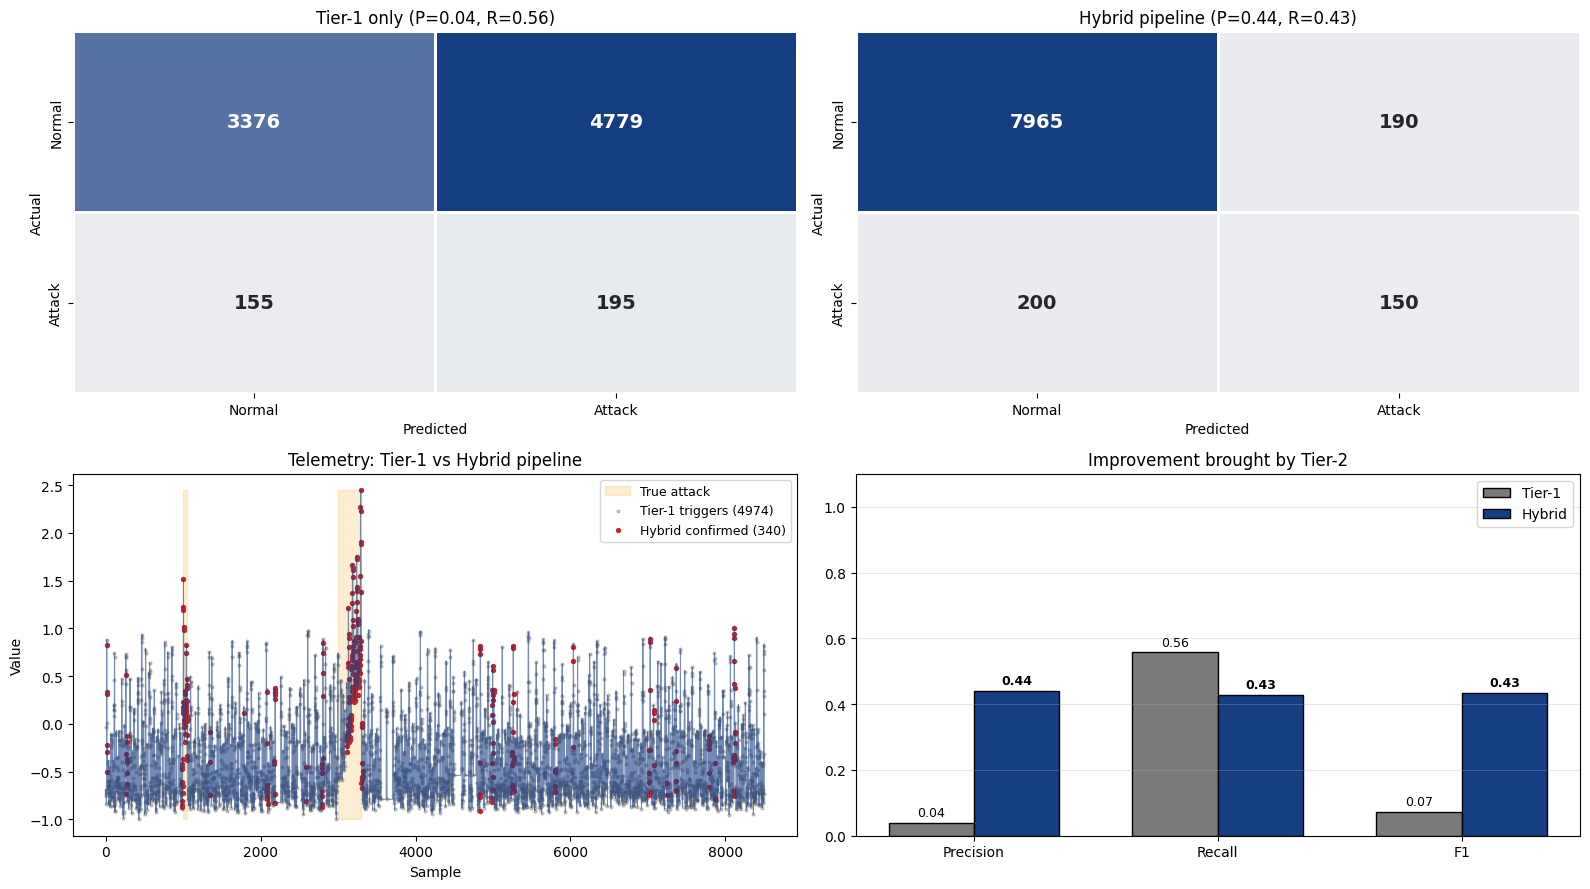

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# (1) Matrices de confusión lado a lado
plot_confusion(y_true, triggers_tier1, f"Tier-1 only (P={prec_t1:.2f}, R={rec_t1:.2f})", ax=axes[0, 0])
plot_confusion(y_true, y_pred_hybrid, f"Hybrid pipeline (P={prec_h:.2f}, R={rec_h:.2f})", ax=axes[0, 1])

# (2) Telemetry with overlaid predictions
ax = axes[1, 0]
ax.plot(attacked_test, color=AERO_BLUE, alpha=0.6, lw=0.7)
ax.fill_between(range(len(y_true)), attacked_test.min(), attacked_test.max(),
                where=y_true == 1, color=AERO_GOLD, alpha=0.3, label='True attack')
# Tier-1 triggers
idx_t1 = np.where(triggers_tier1 == 1)[0]
ax.scatter(idx_t1, attacked_test[idx_t1], color=AERO_GRAY, s=4,
           alpha=0.4, label=f'Tier-1 triggers ({len(idx_t1)})')
# Híbrido (solo los confirmados)
idx_h = np.where(y_pred_hybrid == 1)[0]
ax.scatter(idx_h, attacked_test[idx_h], color=AERO_RED, s=8,
           label=f'Hybrid confirmed ({len(idx_h)})')
ax.set_title("Telemetry: Tier-1 vs Hybrid pipeline")
ax.set_xlabel("Sample"); ax.set_ylabel("Value")
ax.legend(loc='upper right', fontsize=9)

# (3) Comparative bar chart
ax = axes[1, 1]
metrics = ['Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
w = 0.35
vals_t1 = [prec_t1, rec_t1, f1_t1]
vals_h  = [prec_h, rec_h, f1_h]
b1 = ax.bar(x - w/2, vals_t1, w, label='Tier-1', color=AERO_GRAY, edgecolor='black')
b2 = ax.bar(x + w/2, vals_h, w, label='Hybrid',   color=AERO_BLUE, edgecolor='black')
for b, v in zip(b1, vals_t1):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
for b, v in zip(b2, vals_h):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title("Improvement brought by Tier-2")
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
